In [1]:
# Imports and storage configuration
import geopandas as gpd
import pandas as pd
import pystac
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm

import matplotlib.lines as mlines

In [2]:
%pip install s3fs

Note: you may need to restart the kernel to use updated packages.


## Reading the lightning data
-read all lightning clusters

In [3]:
# setup bucket access
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
prefix = 'OSCAssets/storm-data/'

In [4]:
selected_file = 'EC_lightning_clusters.parquet'
#earthcare_id = "01101E"

gdf = gpd.read_parquet(
    f"{bucket}{prefix}{selected_file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    # optional filtering
    #filters=[('earthcare_id', "==", earthcare_id)],
)
#gdf

## Search for cases with GLM and LI data (both)

In [5]:
dfA = gdf[gdf['source'] == 'LI'].sort_values('peak_datetime')
dfB = gdf[gdf['source'] == 'GLM'].sort_values('peak_datetime')
dfA = dfA.rename(columns={'peak_datetime': 'peak_datetime_A'})
dfB = dfB.rename(columns={'peak_datetime': 'peak_datetime_B'})

In [6]:
matched = pd.merge_asof(
    dfA,
    dfB,
    left_on='peak_datetime_A',
    right_on='peak_datetime_B',
    tolerance=pd.Timedelta('1sec'),
    direction='nearest',
    suffixes=('_A', '_B')
)
matched = matched.dropna(subset=['source_B'])
matched = matched.reset_index()
matched["case_A"] = matched.index
matched["case_B"] = matched.index

In [7]:
df1 = matched[[c for c in matched.columns if c.endswith('_A')]]
df1 = df1.rename(columns=lambda c: c.replace('_A', ''))

df2 = matched[[c for c in matched.columns if c.endswith('_B')]]
df2 = df2.rename(columns=lambda c: c.replace('_B', ''))

result = pd.concat([df1, df2], ignore_index=True)
result = result.drop_duplicates()
result = result.sort_values('peak_datetime')

# Box plot

At first, create columns with differences

In [8]:
matched['diff_nadir'] = matched.nadir_lightning_A - matched.nadir_lightning_B

In [9]:
matched['diff_cluster'] = matched.cluster_lightning_A - matched.cluster_lightning_B

Attention, same names in more cells

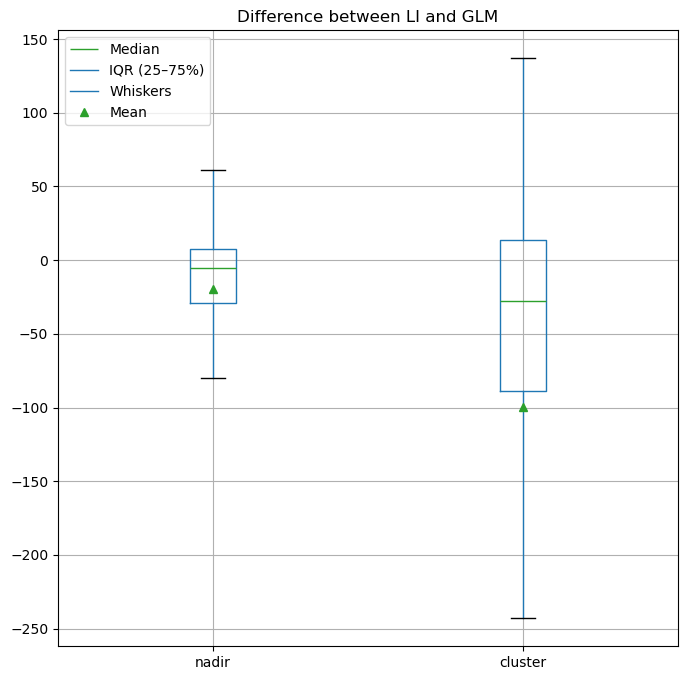

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
ax = matched.boxplot(column=['diff_nadir', 'diff_cluster'], showfliers=False,showmeans=True, return_type='dict')
plt.xticks([1, 2], ['nadir', 'cluster'])
bp = ax#['cluster_lightning_A']
handles = [
    bp['medians'][0],
    bp['boxes'][0],
    bp['whiskers'][0],
    bp['means'][0]
]
labels = [
    'Median',
    'IQR (25–75%)',
    'Whiskers',
    'Mean'
]
plt.legend(handles, labels)
plt.title("Difference between LI and GLM")
plt.show()

In [11]:
fig.savefig("boxplot_comp_LI_GLM_diff.png" )

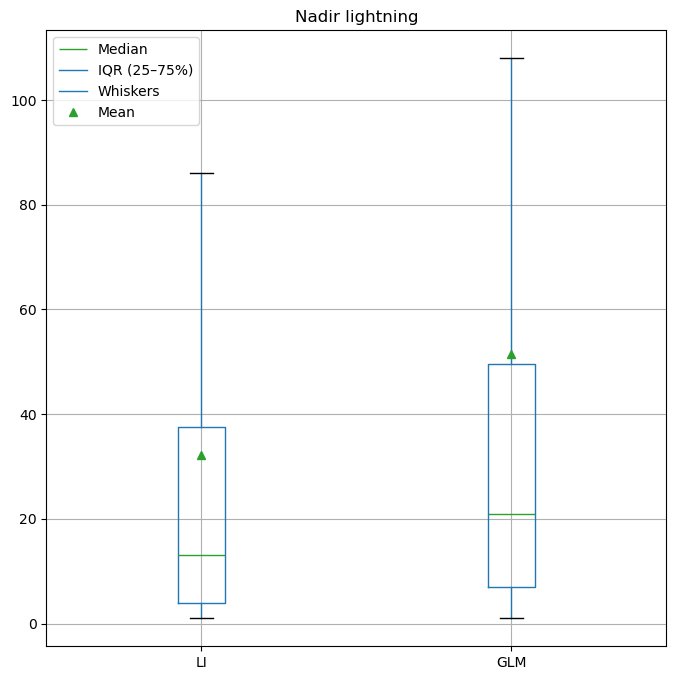

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))
ax = matched.boxplot(column=['nadir_lightning_A', 'nadir_lightning_B'], showfliers=False,showmeans=True, return_type='dict')
plt.xticks([1, 2], ['LI', 'GLM'])
bp = ax#['cluster_lightning_A']
handles = [
    bp['medians'][0],
    bp['boxes'][0],
    bp['whiskers'][0],
    bp['means'][0]
]
labels = [
    'Median',
    'IQR (25–75%)',
    'Whiskers',
    'Mean'
]
plt.legend(handles, labels)
plt.title("Nadir lightning")
plt.show()

In [13]:
fig.savefig("boxplot_comp_LI_GLM_nadir.png" )

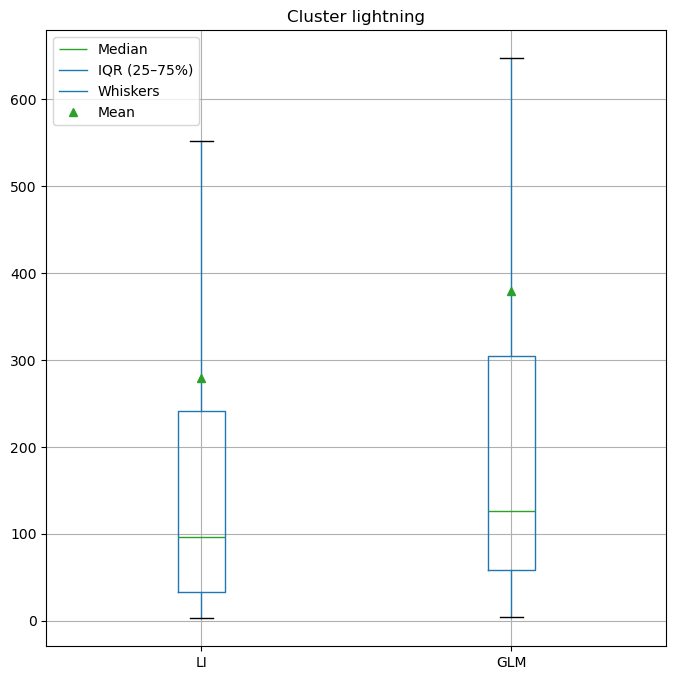

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
ax = matched.boxplot(column=['cluster_lightning_A', 'cluster_lightning_B'], showfliers=False,showmeans=True, return_type='dict')
plt.xticks([1, 2], ['LI', 'GLM'])
bp = ax#['cluster_lightning_A']
handles = [
    bp['medians'][0],
    bp['boxes'][0],
    bp['whiskers'][0],
    bp['means'][0]
]
labels = [
    'Median',
    'IQR (25–75%)',
    'Whiskers',
    'Mean'
]
plt.legend(handles, labels)
plt.title("Cluster lightning")
plt.show()

In [15]:
fig.savefig("boxplot_comp_LI_GLM_cluster.png" )

Statistic in numbers, if you want another parameter, change

In [16]:
stats_A = matched['diff_nadir'].agg([
    'mean',
    'median',
    'std',
    'min',
    'max'
])

print(stats_A)

mean      -19.452261
median     -5.000000
std        83.322948
min      -602.000000
max       291.000000
Name: diff_nadir, dtype: float64


In [17]:
stats_B = matched['diff_cluster'].agg([
    'mean',
    'median',
    'std',
    'min',
    'max'
])

print(stats_B)

mean       -99.633166
median     -28.000000
std        428.439535
min      -3501.000000
max       1208.000000
Name: diff_cluster, dtype: float64


# Plots of tracks

At first, choose the earthcare id

In [18]:
earthcare_id="08484A"

loading tracks from both sources

In [19]:
selected_file_track = 'EC_track_lightning_LI.parquet'

gdf_track_LI = gpd.read_parquet(
        f"{bucket}{prefix}{selected_file_track}",
        storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
        },
        # optional filtering
        filters=[('earthcare_id', "==", earthcare_id)],
    )

In [20]:
selected_file_track = 'EC_track_lightning_GLM.parquet'

gdf_track_GLM = gpd.read_parquet(
        f"{bucket}{prefix}{selected_file_track}",
        storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
        },
        # optional filtering
        filters=[('earthcare_id', "==", earthcare_id)],
    )

In [21]:
i = gdf_track_LI.loc[gdf_track_LI.groupby("geometry")["lightning_count_2p5"].idxmax()]
j = gdf_track_GLM.loc[gdf_track_GLM.groupby("geometry")["lightning_count_2p5"].idxmax()]
i['y'] = i.geometry.y
j['y'] = j.geometry.y
i['x'] = i.geometry.x
j['x'] = j.geometry.x
y_LI = i.sort_values(by="y")
y_GLM = j.sort_values(by="y")
x_LI = i.sort_values(by="x")
x_GLM = j.sort_values(by="x")

(-19.870126724243164, -18.870126724243164)

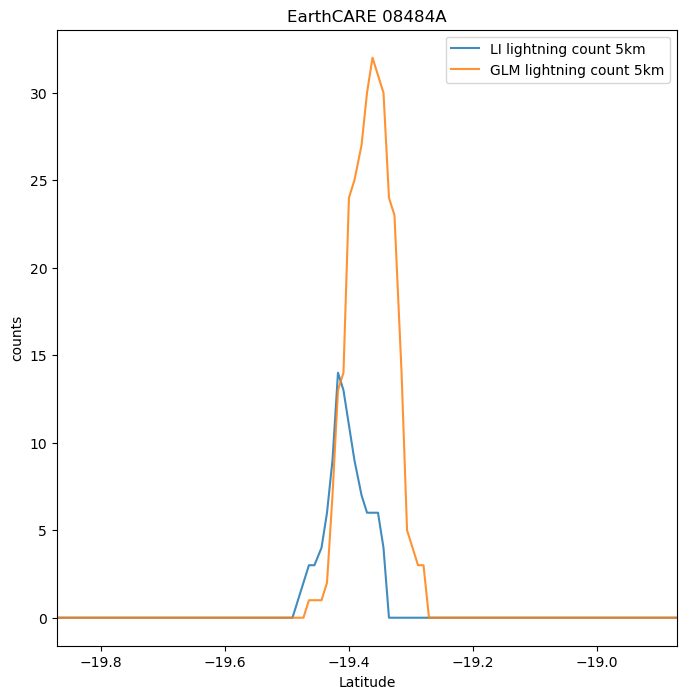

In [27]:
fig, ax = plt.subplots(figsize=(8, 8))
plt.plot(y_LI.y, y_LI.lightning_count_5, alpha=0.85, label="LI lightning count 5km")
plt.plot(y_GLM.y , y_GLM.lightning_count_5, alpha=0.85, label="GLM lightning count 5km")
plt.xlabel("Latitude")
plt.ylabel("counts")
plt.title("EarthCARE " + earthcare_id)
plt.legend()
plt.xlim(gdf.loc[gdf.earthcare_id == earthcare_id].peak_lat.iloc[0]-0.5,gdf.loc[gdf.earthcare_id == earthcare_id].peak_lat.iloc[0]+0.5)
#you can change the zoom, I use +- 0.5

In [23]:
fig.savefig("plot_comp_LI_GLM_" + str(earthcare_id) + "_lat.png" )

(-38.74476623535156, -37.74476623535156)

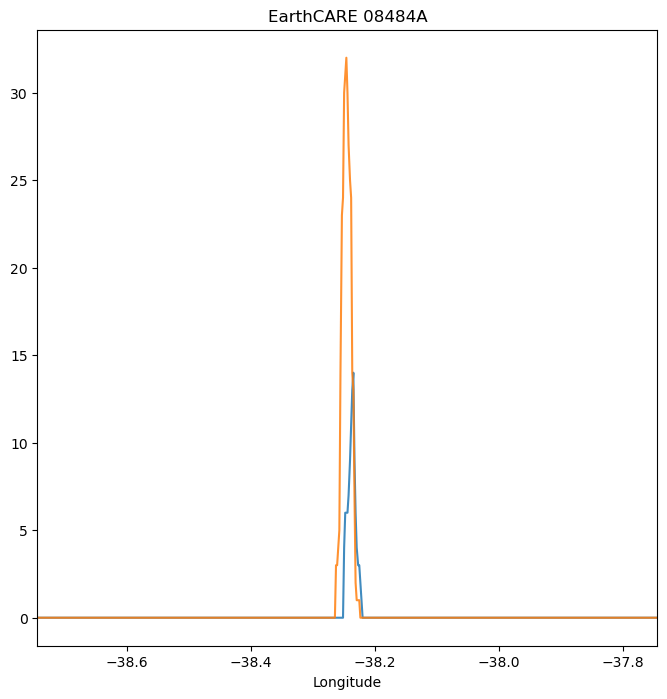

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))
plt.plot(x_LI.x, x_LI.lightning_count_5, alpha=0.85)
plt.plot(x_GLM.x , x_GLM.lightning_count_5, alpha=0.85)
plt.xlabel("Longitude")
plt.title("EarthCARE " + earthcare_id)
plt.xlim(gdf.loc[gdf.earthcare_id == earthcare_id].peak_lon.iloc[0]-0.5,gdf.loc[gdf.earthcare_id == earthcare_id].peak_lon.iloc[0]+0.5)
#you can change the zoom, I use +- 0.5

In [25]:
fig.savefig("plot_comp_LI_GLM_" + str(earthcare_id) + "_lon.png" )